# Fake news Detection using Machine Learning

We will be doing analysis here

## Step 0 : Importing Important Dependencies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from sklearn.model_selection  import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

## Step 1 : Data collection 

we will install / get two types of data 
1. Fake data
2. True data


In [2]:
true_df = pd.read_csv(r"D:\Robotics\Machine Learning Projects\Fake News Detection\data\True.csv")
false_df = pd.read_csv(r"D:\Robotics\Machine Learning Projects\Fake News Detection\data\Fake.csv")

In [3]:
true_df.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [4]:
false_df.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


## Step 3 : EDA

In [5]:
# Lets check the shape of the data
print(f'Shape of true data is {true_df.shape}')
print(f'Shape of false data is {false_df.shape}')

Shape of true data is (21417, 4)
Shape of false data is (23481, 4)


In [6]:
print((21417-23481))

-2064


#### Adding classes to the dataset

In [7]:
false_df["class"]=0
true_df["class"] = 1

In [8]:
false_df.head()

,title,text,subject,date,class
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [9]:
false_df.shape , true_df.shape

((23481, 5), (21417, 5))

In [10]:
fake_manual_testing = false_df.tail(10)
for i in range(23480 , 23470,-1):
    false_df.drop([i] , axis=0 , inplace=True)

true_data_manual_testing = true_df.tail(10)
for i in range(21416,21406,-1):
    true_df.drop([i],axis=0 , inplace=True)

In [11]:
false_df.shape, true_df.shape

((23471, 5), (21407, 5))

In [12]:
true_data_manual_testing["class"]=1
fake_manual_testing["class"]=0

In [13]:
true_data_manual_testing.head()

,title,text,subject,date,class
21407,"Mata Pires, owner of embattled Brazil builder ...","SAO PAULO (Reuters) - Cesar Mata Pires, the ow...",worldnews,"August 22, 2017",1
21408,"U.S., North Korea clash at U.N. forum over nuc...",GENEVA (Reuters) - North Korea and the United ...,worldnews,"August 22, 2017",1
21409,"U.S., North Korea clash at U.N. arms forum on ...",GENEVA (Reuters) - North Korea and the United ...,worldnews,"August 22, 2017",1
21410,Headless torso could belong to submarine journ...,COPENHAGEN (Reuters) - Danish police said on T...,worldnews,"August 22, 2017",1
21411,North Korea shipments to Syria chemical arms a...,UNITED NATIONS (Reuters) - Two North Korean sh...,worldnews,"August 21, 2017",1


In [14]:
data_merge = pd.concat([true_df,false_df ], axis=0)
data_merge.head()

,title,text,subject,date,class
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1


<Axes: >

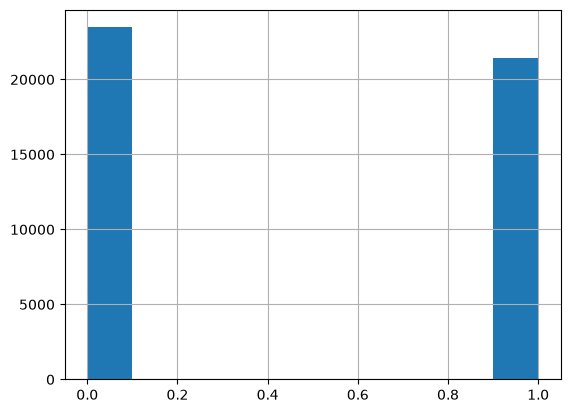

In [17]:
data_merge['class'].hist()

In [18]:
data_merge.columns

Index(['title', 'text', 'subject', 'date', 'class'], dtype='str')

In [36]:
data_v1=data_merge

In [37]:
data_v1.head()

,title,text,subject,date,class
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1


In [38]:
data_v1 = data_v1.drop(["title","subject","date"],axis = 1)

In [39]:
data_v1.head()

,text,class
0,WASHINGTON (Reuters) - The head of a conservat...,1
1,WASHINGTON (Reuters) - Transgender people will...,1
2,WASHINGTON (Reuters) - The special counsel inv...,1
3,WASHINGTON (Reuters) - Trump campaign adviser ...,1
4,SEATTLE/WASHINGTON (Reuters) - President Donal...,1


In [40]:
data_v1.reset_index(inplace=True)
data_v1.drop(['index'],axis=1 , inplace=True)

In [19]:
data =data_merge.drop(["title","subject","date"],axis=1)

In [20]:
data.head()

,text,class
0,WASHINGTON (Reuters) - The head of a conservat...,1
1,WASHINGTON (Reuters) - Transgender people will...,1
2,WASHINGTON (Reuters) - The special counsel inv...,1
3,WASHINGTON (Reuters) - Trump campaign adviser ...,1
4,SEATTLE/WASHINGTON (Reuters) - President Donal...,1


In [21]:
data.reset_index(inplace=True)
data.drop(['index'],axis=1 , inplace=True)

In [31]:
data.head()

,text,class
0,...,1
1,...,1
2,...,1
3,...,1
4,...,1


## Data cleaning

In [41]:
import re
import string

def wordopt(text):
    """
    Clean text with safety checks to prevent empty results
    """
    # Handle empty or None values
    if not text or not isinstance(text, str):
        return "sample_text"
    
    # Store original for fallback
    original = text
    
    # Your original cleaning steps (with fixes)
    text = text.lower()
    text = re.sub(r'\[.*?\]', ' ', text)        # Remove brackets content
    
    # FIX 1: Instead of removing all words, keep only letters, numbers and spaces
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)  # Remove punctuation, keep words
    
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)  # Remove URLs
    text = re.sub(r'<.*?>+', ' ', text)         # Remove HTML tags
    text = re.sub(r'\n', ' ', text)             # Remove newlines
    text = re.sub(r'\s+', ' ', text).strip()    # Remove extra spaces
    
    # FIX 2: If text became empty, recover from original
    if not text:
        # Try to extract meaningful words from original
        words = re.findall(r'[a-zA-Z]+', original)
        if words:
            # Keep first 3 words as fallback
            text = ' '.join(words[:3])
        else:
            # Ultimate fallback
            text = "sample_text"
    
    return text

### **Validating the re function**

In [43]:
sample = """
The QUICK Brown Fox jumps Over The Lazy Dog!! 
In 2026, natural language processing (NLP) requires robust tokenization.
  Are you   ready for this...   or NOT? 
  
  Let's check   how your function,   "wordout", handles tabs	and newlines.  
   NO-SPACE_TEST-123!   
"""

In [44]:
sample = wordopt(sample)

In [45]:
sample

'the quick brown fox jumps over the lazy dog in 2026 natural language processing nlp requires robust tokenization are you ready for this or not let s check how your function wordout handles tabs and newlines no space test 123'

In [30]:
data['text']= data['text'].apply(wordopt)

In [29]:
data.head()

,text,class
0,...,1
1,...,1
2,...,1
3,...,1
4,...,1


In [32]:
x = data['text']
y = data['class']

In [33]:
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.25,random_state=42)

### Reusing wordout function ( after improvement ) 

first version was totaly aggrassive it removed all the things from the text

So here i will check that on new version and the new data variable containing same data

In [46]:
data_v1['text']= data_v1['text'].apply(wordopt)

In [47]:
data_v1.head()

,text,class
0,washington reuters the head of a conservative ...,1
1,washington reuters transgender people will be ...,1
2,washington reuters the special counsel investi...,1
3,washington reuters trump campaign adviser geor...,1
4,seattle washington reuters president donald tr...,1


In [48]:
data_v1['text']

0        washington reuters the head of a conservative ...
1        washington reuters transgender people will be ...
2        washington reuters the special counsel investi...
3        washington reuters trump campaign adviser geor...
4        seattle washington reuters president donald tr...
                               ...                        
44873    21st century wire says for those who still ref...
44874    21st century wire says so far after nearly 20 ...
44875    21st century wire says if you ve been followin...
44876    tune in to the alternate current radio network...
44877    rtone of the most visible members of the armed...
Name: text, Length: 44878, dtype: str

### Spliting the data with train 

In [49]:
x1 = data_v1['text']
y1 = data_v1['class']

In [50]:
x1_train , x1_test , y1_train , y1_test = train_test_split(x1,y1,test_size=0.25 , random_state=42)

In [51]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorization = TfidfVectorizer()
xv_train = vectorization.fit_transform(x1_train)
xv_test = vectorization.transform(x1_test)

## Model Training

### **First Model to train**

In [53]:
from sklearn.linear_model import LogisticRegression
LR = LogisticRegression()
LR.fit(xv_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol